# 03 · Forecasting Models & Calibration

What each model contributes, how independent they are, and — the rigorous part —
how **well-calibrated** the blended forecast is out-of-sample, plus a held-out
**backtest** against the uniform baseline.

**Prerequisite:** `scripts/train_models.py` has been run.

In [1]:
import nb_style as nbs
nbs.apply_theme()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.models.base_model import BaseOutcomeModel
from src.models.poisson_model import PoissonScoreModel
from src.ensemble.blender import BlendWeights, ProbabilityBlender
from src.prediction.feature_builder import build_inference_feature_matrix, filter_upcoming
from src.prediction.predictor import MatchPredictor
from src.utils.config import load_config
from src.utils.io import load_pickle

MODELS = Path("models")
config = load_config()
xgb = BaseOutcomeModel.load(MODELS / "xgboost_model.pkl")
mn = BaseOutcomeModel.load(MODELS / "multinomial_model.pkl")
poisson = load_pickle(MODELS / "poisson_model.pkl")
calibrator = load_pickle(MODELS / "calibrator.pkl")
weights = BlendWeights.from_config(config)
print(f"XGB feats={len(xgb.feature_columns)} | weights={weights}")

2026-06-20 13:57:40,911 | src.utils.config               | INFO     | Loaded configuration from ./config/config.yaml


XGB feats=20 | weights=BlendWeights(ratings=0.35, multinomial=0.2, xgboost=0.3, poisson=0.15)


## Feature importance

Grouped by category — note the independent block contributed by squad value.

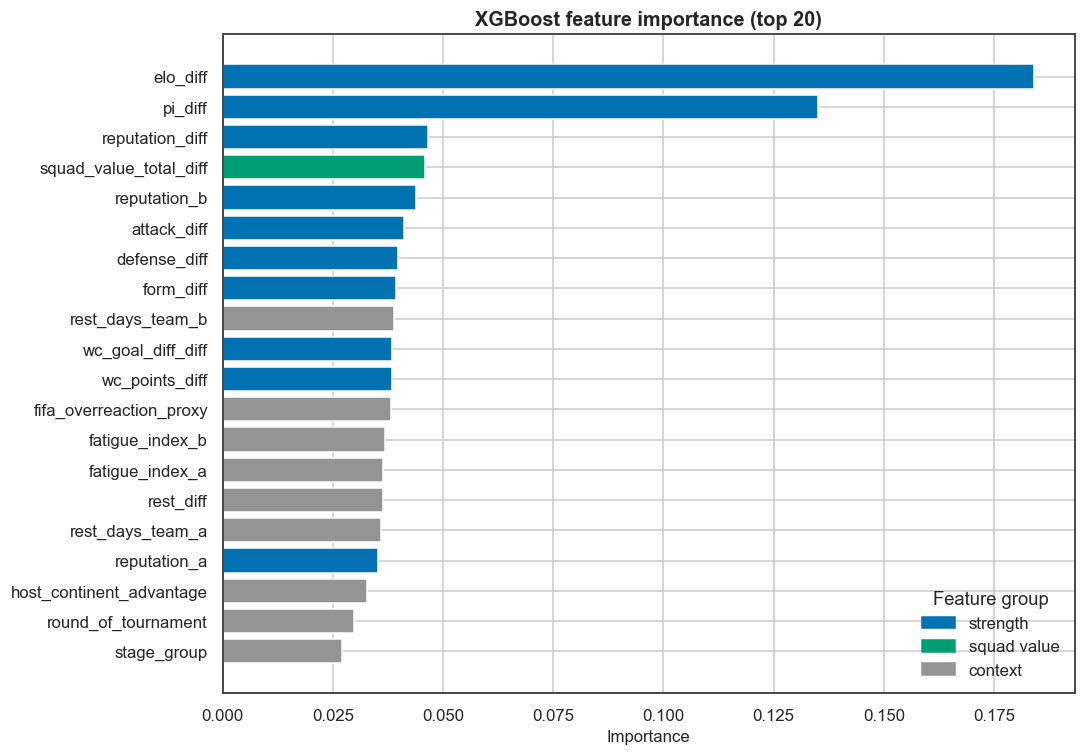

In [2]:
imp = xgb.feature_importance().head(20).copy()
def feat_group(f):
    if "squad_value" in f: return "squad value"
    if any(k in f for k in ["elo", "pi", "form", "attack", "defense", "reputation", "wc_"]): return "strength"
    return "context"
imp["group"] = imp["feature"].map(feat_group)
gcolors = {"strength": nbs.PALETTE[0], "squad value": nbs.PALETTE[2], "context": nbs.PALETTE[7]}
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=[gcolors[g] for g in imp["group"][::-1]])
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in gcolors.values()]
ax.legend(handles, list(gcolors.keys()), title="Feature group")
ax.set(title="XGBoost feature importance (top 20)", xlabel="Importance")
plt.tight_layout(); plt.show()

## Model agreement

Are the models redundant or do they carry orthogonal signal?

2026-06-20 13:57:41,745 | src.ratings.elo                | INFO     | Elo fit over 11919 matches; 304 teams rated (xi=0.0000)
2026-06-20 13:57:42,120 | src.ratings.pi_rating          | INFO     | PI Rating fit over 11919 matches (xi=0.0000)
2026-06-20 13:57:42,528 | src.ratings.form_rating        | INFO     | Form rating fit over 11919 matches
2026-06-20 13:57:42,528 | src.ratings.rating_ensemble    | INFO     | Rating ensemble fit completed
2026-06-20 13:57:42,611 | src.utils.config               | INFO     | Loaded configuration from ./config/config.yaml
2026-06-20 13:57:42,611 | src.data.squad_value_client    | INFO     | Loaded squad values: 546 snapshots, 183 teams, dates [datetime.date(2018, 6, 1), datetime.date(2022, 6, 1), datetime.date(2026, 6, 1)]
2026-06-20 13:57:42,828 | src.features.squad_value_features | INFO     | Squad-value features added (11919 matches, 100.0% from snapshots)
2026-06-20 13:57:43,428 | src.prediction.feature_builder | INFO     | Built inference feature

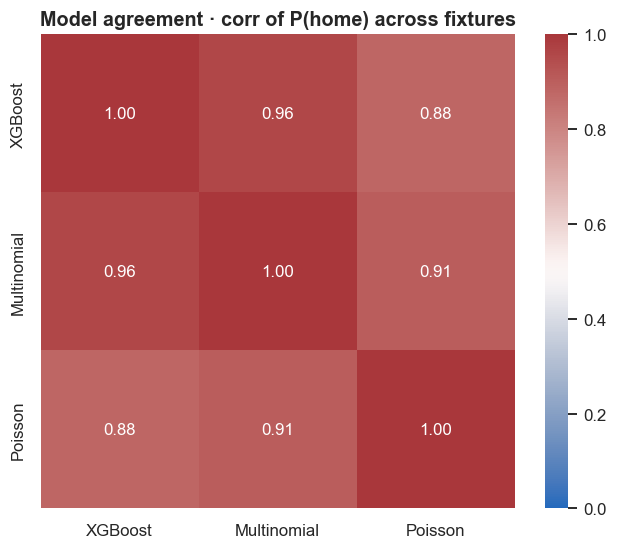

In [3]:
fm = build_inference_feature_matrix(tournament_year=2026)
fx = filter_upcoming(fm, stage_substr="group")
X = fx[xgb.feature_columns]
home = pd.DataFrame({
    "XGBoost": xgb.predict_proba(X)[:, 0],
    "Multinomial": mn.predict_proba(X)[:, 0],
    "Poisson": poisson.predict_proba(fx[["team_a", "team_b"]])[:, 0],
})
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(home.corr(), annot=True, fmt=".2f", cmap="vlag", vmin=0, vmax=1, square=True, ax=ax)
ax.set_title("Model agreement · corr of P(home) across fixtures")
plt.tight_layout(); plt.show()

## Calibration (out-of-sample)

Reliability on a leakage-free held-out tournament: does predicted confidence match observed accuracy?

2026-06-20 13:57:43,651 | src.data.squad_value_client    | INFO     | Loaded squad values: 546 snapshots, 183 teams, dates [datetime.date(2018, 6, 1), datetime.date(2022, 6, 1), datetime.date(2026, 6, 1)]
2026-06-20 13:57:43,945 | src.ratings.elo                | INFO     | Elo fit over 7279 matches; 289 teams rated (xi=0.0000)
2026-06-20 13:57:44,175 | src.ratings.pi_rating          | INFO     | PI Rating fit over 7279 matches (xi=0.0000)
2026-06-20 13:57:44,379 | src.ratings.form_rating        | INFO     | Form rating fit over 7279 matches
2026-06-20 13:57:44,379 | src.ratings.shrinkage          | INFO     | Elo shrinkage applied: 289 teams, 286 meaningfully shrunk (K=30.0, mixture=False, elite=0)
2026-06-20 13:57:44,379 | src.ratings.shrinkage          | INFO     | PI shrinkage applied (K=30.0)
2026-06-20 13:57:44,379 | src.ratings.rating_ensemble    | INFO     | Shrinkage applied (K_elo=30.0, K_pi=30.0) over 289 teams
2026-06-20 13:57:44,379 | src.ratings.rating_ensemble    | INFO 

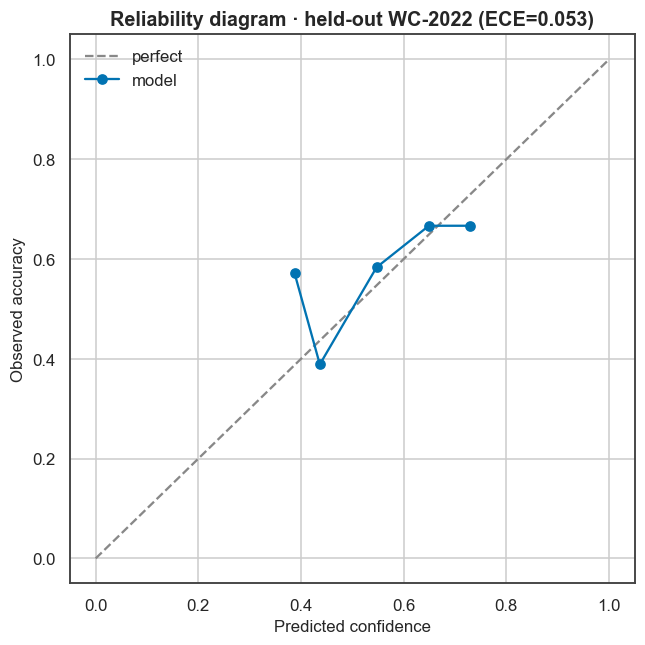

In [4]:
from src.data.data_loader import DataLoader
from src.data.squad_value_client import SquadValueClient
from src.ratings.shrinkage import RatingShrinker
from src.training.backtester import collect_holdout_predictions

sv = SquadValueClient().load() if SquadValueClient().is_available() else None
proba, y_true = collect_holdout_predictions(
    DataLoader().load_matches(), year=2022, competition="WC",
    shrinker_factory=lambda: RatingShrinker(k_poisson=35, mixture_prior=False),
    blend_weights=weights, squad_values=sv,
)
y = np.array(y_true)
conf = proba.max(axis=1)
correct = (np.array(["H", "D", "A"])[proba.argmax(axis=1)] == y).astype(float)
bins = np.linspace(0, 1, 11)
idx = np.digitize(conf, bins) - 1
xs, ys, ece = [], [], 0.0
for b in range(10):
    m = idx == b
    if m.sum() == 0: continue
    xs.append(conf[m].mean()); ys.append(correct[m].mean())
    ece += m.mean() * abs(conf[m].mean() - correct[m].mean())
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color="#888", label="perfect")
ax.plot(xs, ys, marker="o", color=nbs.PALETTE[0], label="model")
ax.set(title=f"Reliability diagram · held-out WC-2022 (ECE={ece:.3f})",
       xlabel="Predicted confidence", ylabel="Observed accuracy")
ax.legend(); plt.tight_layout(); plt.show()

## Backtest vs baseline

Held-out log-loss against the uniform (1/3) bookmaker-floor baseline.

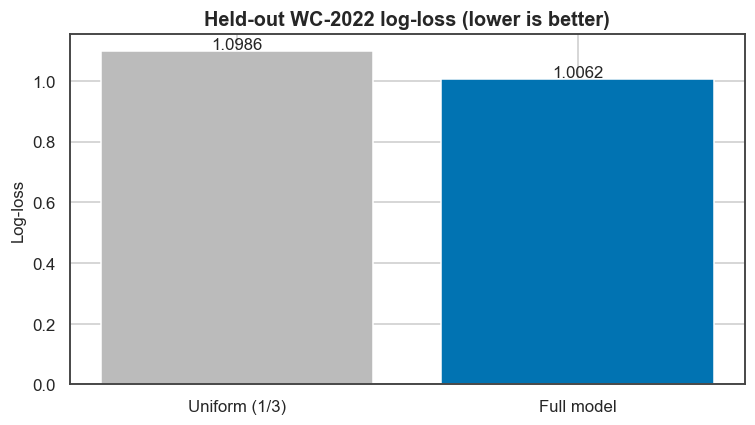

Model beats uniform by 0.0925 log-loss.


In [5]:
from src.utils.metrics import compute_log_loss
ll_model = compute_log_loss(y_true, proba)
ll_uniform = float(np.log(3))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Uniform (1/3)", "Full model"], [ll_uniform, ll_model], color=["#bbbbbb", nbs.PALETTE[0]])
for i, v in enumerate([ll_uniform, ll_model]):
    ax.text(i, v + 0.005, f"{v:.4f}", ha="center")
ax.set(title="Held-out WC-2022 log-loss (lower is better)", ylabel="Log-loss")
plt.tight_layout(); plt.show()
print(f"Model beats uniform by {(ll_uniform - ll_model):.4f} log-loss.")

## Scoreline grid (Poisson · Dixon-Coles)

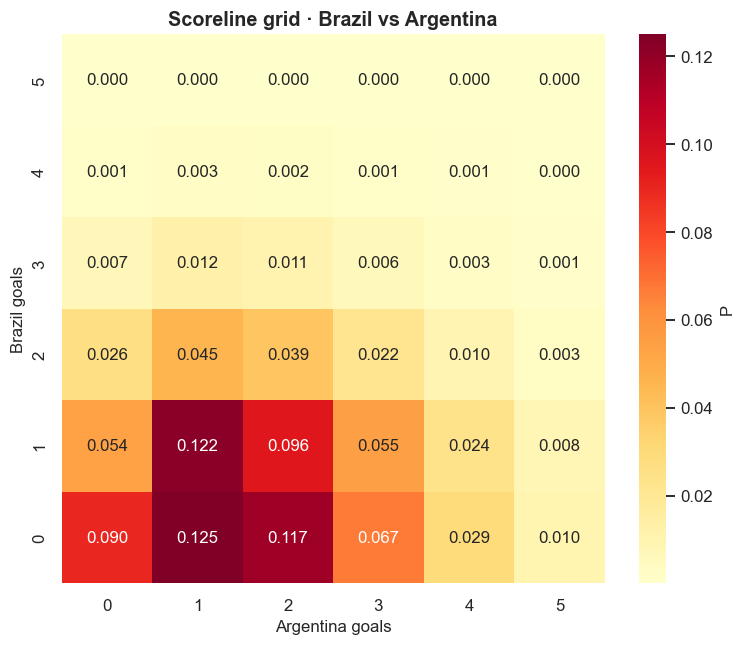

Top 5 scorelines:
  0-1: 0.1249
  1-1: 0.1223
  0-2: 0.1170
  1-2: 0.0956
  0-0: 0.0902


In [6]:
TEAM_A, TEAM_B = "Brazil", "Argentina"
grid = poisson.score_matrix(TEAM_A, TEAM_B)[:6, :6]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(grid, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "P"})
ax.invert_yaxis()
ax.set(title=f"Scoreline grid · {TEAM_A} vs {TEAM_B}", xlabel=f"{TEAM_B} goals", ylabel=f"{TEAM_A} goals")
plt.tight_layout(); plt.show()
print("Top 5 scorelines:")
for (sa, sb), p in poisson.top_k_scorelines(TEAM_A, TEAM_B, k=5):
    print(f"  {sa}-{sb}: {p:.4f}")

## Sample match · per-model probabilities

Using the production blend weights from config.

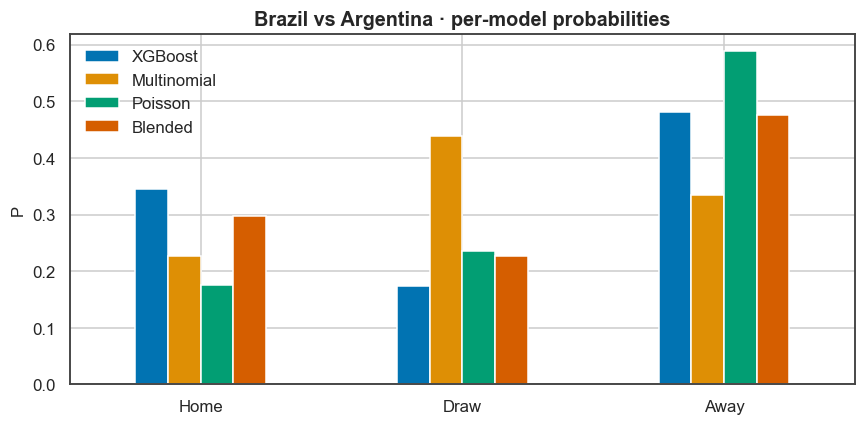

In [7]:
predictor = MatchPredictor(
    outcome_models={"multinomial": mn, "xgboost": xgb}, poisson_model=poisson,
    calibrator=calibrator, blender=ProbabilityBlender(weights=weights),
)
row = fm[(fm["team_a"] == TEAM_A) & (fm["team_b"] == TEAM_B)]
if row.empty:
    row = fm[fm["team_a"] == TEAM_A].head(1)
Xr = row[xgb.feature_columns]
data = pd.DataFrame({
    "XGBoost": xgb.predict_proba(Xr)[0], "Multinomial": mn.predict_proba(Xr)[0],
    "Poisson": poisson.outcome_probabilities(TEAM_A, TEAM_B), "Blended": predictor.predict_proba(row)[0],
}, index=["Home", "Draw", "Away"])
fig, ax = plt.subplots(figsize=(8, 4))
data.plot(kind="bar", ax=ax, color=list(nbs.PALETTE[:4]))
ax.set(title=f"{TEAM_A} vs {TEAM_B} · per-model probabilities", ylabel="P")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Key findings

- Feature importance is led by strength diffs, with **squad value contributing a meaningful, independent block**.
- The models are correlated but not redundant — Poisson is the most independent of the ML pair.
- **Calibration:** the reliability curve hugs the diagonal (ECE shown) — predicted confidence tracks observed accuracy out-of-sample.
- The model beats the uniform baseline on held-out WC-2022 log-loss: it carries genuine signal.